In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



# Load data
df = pd.read_csv(r"C:\Users\lenovo\Downloads\ford.csv")

# Features & target
X = df.drop('price', axis=1)
y = df['price']

# Encoding
X = pd.get_dummies(X, drop_first=True,dtype = int)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# # -------------------
# # Linear Regression
# # -------------------
# lr_model = LinearRegression()
# lr_model.fit(X_train, y_train)

# y_pred_lr = lr_model.predict(X_test)

# -------------------
# Scaling (for ANN)
# -------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------
# ANN Model
# -------------------
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear')) 

model.compile(loss='mse', optimizer='adam', metrics=['r2_score'])

history = model.fit(X_train_scaled, y_train,epochs=20,validation_data=(X_test_scaled, y_test))

# ypred = model.predict(x_test_scaled, y_test)



Epoch 1/20


c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 80939656.0000 - r2_score: -2.7099 - val_loss: 3776686.2500 - val_r2_score: 0.8497
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3185519.0000 - r2_score: 0.8540 - val_loss: 3081830.7500 - val_r2_score: 0.8773
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2842514.7500 - r2_score: 0.8697 - val_loss: 2851833.0000 - val_r2_score: 0.8865
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2682510.7500 - r2_score: 0.8770 - val_loss: 2729344.7500 - val_r2_score: 0.8914
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2570998.7500 - r2_score: 0.8822 - val_loss: 2669618.7500 - val_r2_score: 0.8937
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2500271.5000 - r2_score: 0.8854 - val_loss: 2578157.0000 - val_r2_score: 0.8974
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2457470.5000 - r2_score: 0.8874 - val_loss: 2557009.2500 - val_r2_score: 0.8982
Epoch 8/20
450/450 ━━━━━━━━━━

In [2]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,981 (58.52 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,988 (39.02 KB)

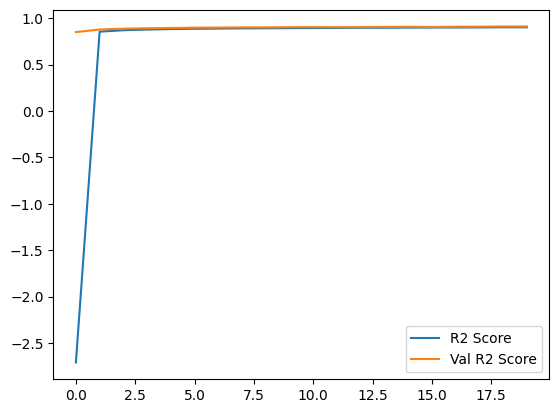

In [3]:
import matplotlib.pyplot as plt
plt.plot(history.history['r2_score'], label='R2 Score')
plt.plot(history.history['val_r2_score'], label='Val R2 Score')
# plt.plot(history.history['loss'], label='Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()